# Viscoelastic wave propagator with Maxwell - GSLS formulation #

This tutorial was prepared by Paula Neves de Araujo (paulan@ime.usp.br). It introduces the Spyro viscoelastic wave propagator using the Maxwell–GSLS formulation.

The generalized Maxwell model is a viscoelastic model that extends the classical Maxwell model by incorporating multiple relaxation mechanisms. It represents the material response as an elastic spring in parallel with several Maxwell elements, each consisting of a spring and a dashpot in series.

<center><img src="generalized_maxwell_diagram.png" width="300"></center>

This structure allows the GSLS model to reproduce a wide range of attenuation and dispersion behaviors by fitting the observed frequency-dependent quality factor Q(f) more accurately than simpler models. In this work, the following formulation for the viscoelastic wave equation is presented:

$$
\begin{split}
\rho \,\partial_t \mathbf{v}(\mathbf{x}, t) &= D\boldsymbol{\sigma}(\mathbf{x}, t) + \mathbf{f}_v(\mathbf{x}, t), \\
\partial_t \boldsymbol{\sigma}(\mathbf{x}, t) &= \mathbf{C} D^\top \mathbf{v}(\mathbf{x}, t)
- (\mathbf{C} : \boldsymbol{\Gamma})(\mathbf{x}) \sum_{\ell = 1}^{L} y_\ell \boldsymbol{\xi}_\ell(\mathbf{x}, t), \\
\partial_t \boldsymbol{\xi}_\ell(\mathbf{x}, t) + \omega_\ell \boldsymbol{\xi}_\ell(\mathbf{x}, t)
&= \omega_\ell D^\top \mathbf{v}(\mathbf{x}, t), \qquad \ell = 1, \dots, L.
\end{split}
$$

Here, $\boldsymbol{\Gamma}$ is the tensor of reciprocals of the quality-factor values $Q$. Therefore, we have the following characterization of $\boldsymbol{\Gamma}$:

$$
\boldsymbol{\Gamma} =
\begin{pmatrix}
Q_{11}^{-1} & Q_{12}^{-1} & Q_{13}^{-1} & Q_{14}^{-1} & Q_{15}^{-1} & Q_{16}^{-1} \\
Q_{21}^{-1} & Q_{22}^{-1} & Q_{23}^{-1} & Q_{24}^{-1} & Q_{25}^{-1} & Q_{26}^{-1} \\
Q_{31}^{-1} & Q_{32}^{-1} & Q_{33}^{-1} & Q_{34}^{-1} & Q_{35}^{-1} & Q_{36}^{-1} \\
Q_{41}^{-1} & Q_{42}^{-1} & Q_{43}^{-1} & Q_{44}^{-1} & Q_{45}^{-1} & Q_{46}^{-1} \\
Q_{51}^{-1} & Q_{52}^{-1} & Q_{53}^{-1} & Q_{54}^{-1} & Q_{55}^{-1} & Q_{56}^{-1} \\
Q_{61}^{-1} & Q_{62}^{-1} & Q_{63}^{-1} & Q_{64}^{-1} & Q_{65}^{-1} & Q_{66}^{-1}
\end{pmatrix}.
$$

The GSLS–Maxwell formulation provides a flexible framework to approximate nearly constant-$Q$ behavior over a broad frequency range, making it particularly suitable for seismic wave propagation and anelastic attenuation modeling in geophysical simulations.

The parameters $\omega_\ell$ are reference frequencies, logarithmically distributed over a frequency range for which a nearly constant value of $Q$ is desired. The parameters $y_\ell$ are computed by solving the following minimization problem:

$$
\min_{y_\ell} \chi^{Q_{IJ}(\mathbf{x})},
\qquad
\chi^{Q_{IJ}(\mathbf{x})}
=
\int_{\omega_{\min}}^{\omega_{\max}}
\left(
\sum_{\ell=1}^{L}
y_\ell(\mathbf{x})
\frac{\omega_\ell \omega}{\omega^2 + \omega_\ell^2}
- 1
\right)^2 d\omega.
$$

First, the notebook environment is configured and the required modules are imported. If you are running this notebook in Google Colab, copy the following code block before executing the notebook.

```python
# For use in colab only:
try:
    import firedrake
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/firedrake-install-real.sh" -O "/tmp/firedrake-install.sh" && bash "/tmp/firedrake-install.sh"
    import firedrake

!pip install git+https://github.com/NDF-Poli-USP/spyro.git

In [ ]:
%matplotlib inline
import spyro
import numpy as np

from firedrake import *

We define the basic parameters for the simulation:

In [ ]:
source_location = (-500.0, 500.0)
# (z, x) coordinates of the source. Note that the first coordinate is negative due to
# the standard domain construction used by Spyro.

receiver_location = spyro.create_transect(
    (-450.0,  50.0),
    (-450.0,  950.0),
    300
)
# 300 receivers distributed along a line located 50 meters away from the source.

dx_target = 10.0      # target spatial spacing
dt = 0.0005          # time step
final_time = 0.4      # total simulation time
frequency = 10.0      # peak frequency of the source function

domain_size = 1000.0  # domain size in each dimension

rho = 2000.0          # density
vp = 2500.0           # P-wave velocity
vs = vp / 1.732       # S-wave velocity
mu = rho * vs**2      # Lamé parameter
lmbda = rho * (vp**2 - 2 * vs**2)  # Lamé parameter

amplitude = np.array([0.0, 5e7])  # source amplitude in the x direction

# Parameters for the GSLS formulation
fmin = 1e-1          # minimum frequency considered in the attenuation model
fmax = 3 * frequency # maximum frequency considered in the attenuation model
L = 5                # number of attenuation branches
nf = 100             # number of frequency samples used in the integral

Q0 = 20              # quality factor for the material

The following dictionary defines the problem parameters:

In [ ]:
base_dictionary = {
    "options": {
        "cell_type": "T",
        "variant": "lumped",
        "degree": 2,
        "dimension": 2,
    },
    "wave_type": "isotropic",
    "parallelism": {"type": "automatic"},
    "mesh": {
        "length_z": domain_size,
        "length_x": domain_size,
        "mesh_file": None,
        "mesh_type": "firedrake_mesh",
    },
    "acquisition": {
        "source_type": "ricker",
        "source_locations": [source_location],
        "frequency": frequency,
        "delay": 0.2,
        "delay_type": "time",
        "receiver_locations": receiver_location,
        "amplitude": amplitude,
    },
    "time_axis": {
        "initial_time": 0.0,
        "final_time": final_time,
        "dt": dt,
        "output_frequency": 100,
        "gradient_sampling_frequency": 1,
    },
    "visualization": {
        "forward_output": True,
        "forward_output_filename": "results/forward_output.pvd",
        "fwi_velocity_model_output": False,
        "velocity_model_filename": None,
        "gradient_output": False,
        "gradient_filename": "results/Gradient.pvd",
        "adjoint_output": False,
        "adjoint_filename": None,
        "debug_output": False,
    },
    "synthetic_data": {
        "type": "object",
        "density": rho,
        "p_wave_velocity": vp,
        "s_wave_velocity": vs,
        "Q_vp": 1 / 30,   # reciprocal of the P-wave quality factor
        "Q_vs": 1 / 30,   # reciprocal of the S-wave quality factor
        "real_velocity_file": None,
    },
}

The following code computes the coefficients $y_\ell$ and the relaxation frequencies $\omega_\ell$:

In [ ]:
def compute_y_coefficients(fmin, fmax, L, nfreqs=100):
    # Relaxation frequencies logarithmically distributed between fmin and fmax
    freqs_relax = np.logspace(np.log10(fmin), np.log10(fmax), L)

    omega_relax = 2 * np.pi * freqs_relax

    # Frequency samples used for the integral
    f_sample = np.linspace(fmin, fmax, nfreqs)
    omega_sample = 2 * np.pi * f_sample

    # Build the matrix A used in the least-squares problem A y = b
    A = np.zeros((nfreqs, L))

    for i, w in enumerate(omega_sample):
        for j, wl in enumerate(omega_relax):
            A[i, j] = (wl * w) / (w**2 + wl**2)

    b = np.ones(nfreqs)
    y, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
    return y, omega_relax

y, omega_relax = compute_y_coefficients(fmin, fmax, L, nfreqs=nf)

For this formulation, we also define a dictionary containing the viscoelastic parameters:

In [ ]:
viscoelastic_dictionary = base_dictionary.copy()
viscoelastic_dictionary["viscoelastic"] = True

viscoelastic_dictionary["viscoelasticity"] = {
    "visco_type": "maxwell_gsls_Q",
    "Q_type": "constant",
    "branches": L,
    "omega_gsls": omega_relax,
    "y_gsls": y,
}

Next, we build the wave object and define a periodic mesh for this example:

In [ ]:
viscoelastic_wave = spyro.IsotropicWave(viscoelastic_dictionary)

viscoelastic_wave.set_mesh(input_mesh_parameters={"edge_length": dx_target, "periodic": True})

Parallelism type: automatic
No Absorbing Boundary Conditions (ABCs) applied.
Pad length will be determined with HABC criterion
Mesh incomplete: 'firedrake_mesh' requires either 'edge_length' or 'cells_per_wavelength'.
Mesh incomplete: 'firedrake_mesh' requires either 'edge_length' or 'cells_per_wavelength'.
Skipping mesh generation, since we don't have all the parameters
Creating firedrake_mesh type mesh.


/home/paulanevesdearaujo/spyro/spyro/solvers/wave.py:171: UserWarning: No mesh file, Firedrake mesh will be automatically generated.
  warnings.warn(


Mesh Created with 10000 Nodes and 20000 Area Elements


Finally, the wave propagation can be performed:

In [ ]:
viscoelastic_wave.forward_solve()


Solving Forward Problem
Viscoelastic Maxwell GSLS
Saving Displacement in: results/forward_outputsn[0].pvd
Simulation time is:        0.0 seconds
Simulation time is:       0.05 seconds
Simulation time is:        0.1 seconds
Simulation time is:       0.15 seconds
Simulation time is:        0.2 seconds
Simulation time is:       0.25 seconds
Simulation time is:        0.3 seconds
Simulation time is:       0.35 seconds
Simulation time is:        0.4 seconds


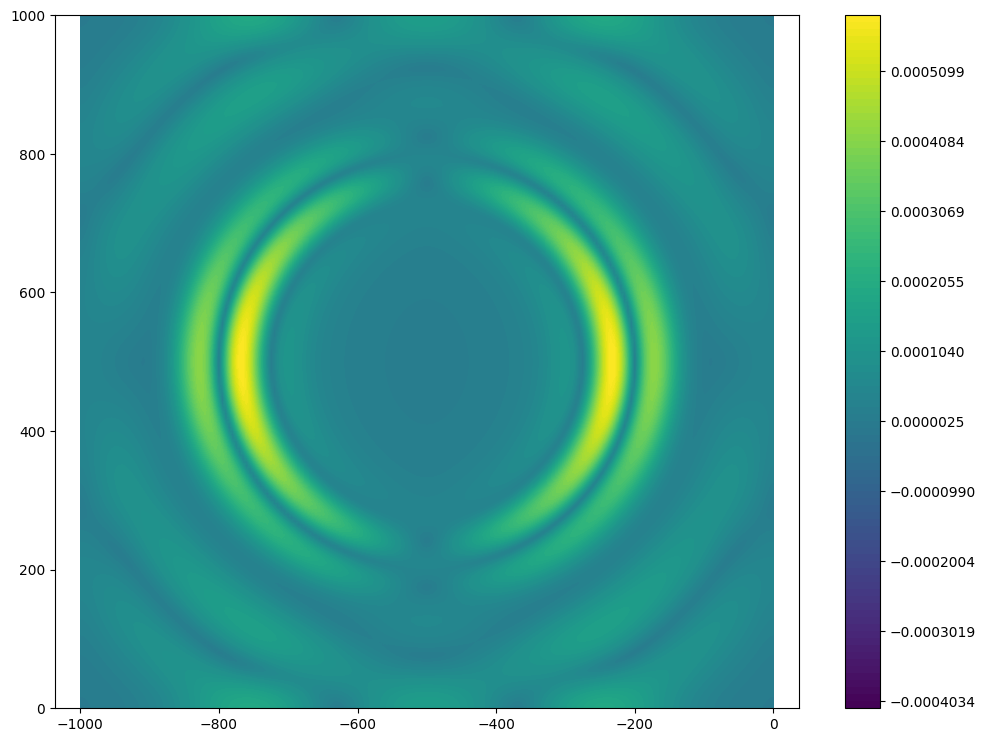

In [ ]:
import matplotlib.pyplot as plt

vmin = np.min(viscoelastic_wave.u_n.dat.data)
vmax = np.max(viscoelastic_wave.u_n.dat.data)   

fig = plt.figure(figsize=(12, 9))
axes = fig.add_subplot(111)
levels = np.linspace(vmin, vmax, 100)
contours = tricontourf(
        viscoelastic_wave.u_n, 
        axes=axes,
        levels=levels,
        vmin=vmin,
        vmax=vmax
    )
axes.axis('equal')
cbar = plt.colorbar(contours, ax=axes)

For comparison between viscoelastic and elastic cases, we define another dictionary without the viscoelasticity parameters and run the simulation in the same way:

In [ ]:
elastic_dictionary = base_dictionary.copy()

In [ ]:
elastic_wave = spyro.IsotropicWave(elastic_dictionary)

elastic_wave.set_mesh(input_mesh_parameters={"edge_length": dx_target, "periodic": True})

Parallelism type: automatic
No Absorbing Boundary Conditions (ABCs) applied.
Pad length will be determined with HABC criterion
Mesh incomplete: 'firedrake_mesh' requires either 'edge_length' or 'cells_per_wavelength'.
Mesh incomplete: 'firedrake_mesh' requires either 'edge_length' or 'cells_per_wavelength'.
Skipping mesh generation, since we don't have all the parameters
Creating firedrake_mesh type mesh.


/home/paulanevesdearaujo/spyro/spyro/solvers/wave.py:171: UserWarning: No mesh file, Firedrake mesh will be automatically generated.
  warnings.warn(


Mesh Created with 10000 Nodes and 20000 Area Elements


In [ ]:
elastic_wave.forward_solve()


Solving Forward Problem
Saving Displacement in: results/forward_outputsn[0].pvd
Simulation time is:        0.0 seconds
Simulation time is:       0.05 seconds
Simulation time is:        0.1 seconds
Simulation time is:       0.15 seconds
Simulation time is:        0.2 seconds
Simulation time is:       0.25 seconds
Simulation time is:        0.3 seconds
Simulation time is:       0.35 seconds
Simulation time is:        0.4 seconds


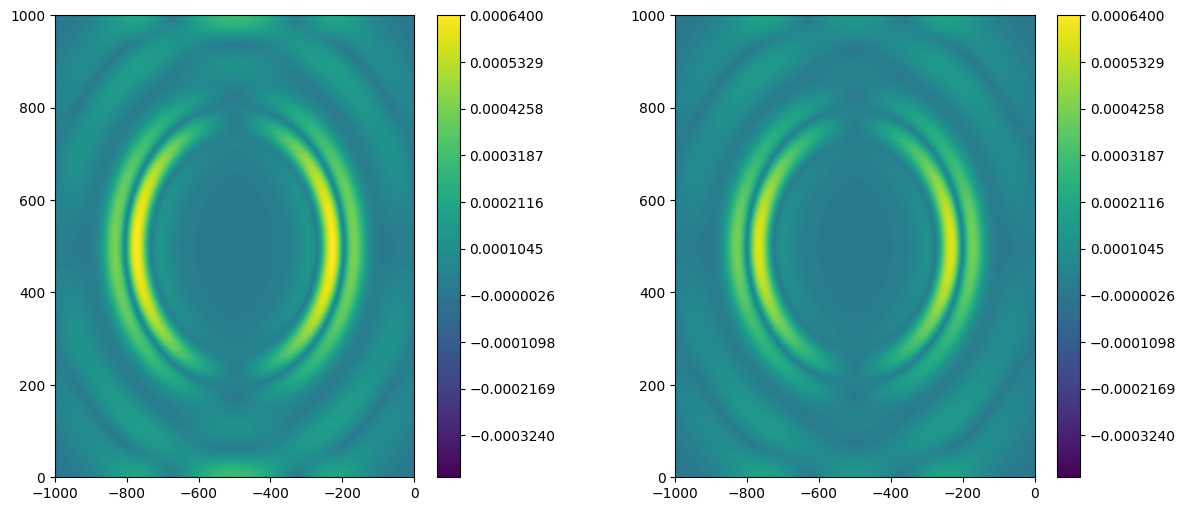

In [ ]:
vmin = np.min(elastic_wave.u_n.dat.data)
vmax = np.max(elastic_wave.u_n.dat.data)
levels = np.linspace(vmin, vmax, 100)

fig = plt.figure(figsize=(12, 6))
subfigs = fig.subfigures(1, 2, wspace=0.07)

ax0 = subfigs[0].add_subplot(111)
contours1 = tricontourf(
    elastic_wave.u_n,
    axes=ax0,
    levels=levels,
    vmin=vmin,
    vmax=vmax
)
plt.colorbar(contours1, ax=ax0)

ax1 = subfigs[1].add_subplot(111)
contours2 = tricontourf(
    viscoelastic_wave.u_n,
    axes=ax1,
    levels=levels,
    vmin=vmin,
    vmax=vmax
)
plt.colorbar(contours2, ax=ax1)

plt.show()

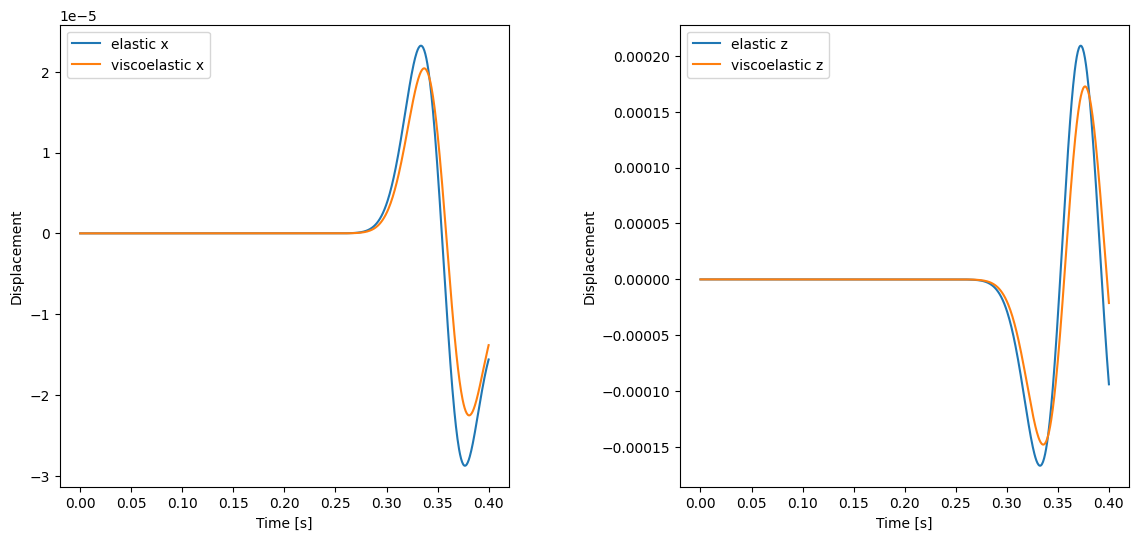

In [ ]:
def get_time_vector(wave):
    """Get a time vector representing the time axis of a wave object."""
    number_timesteps = int(wave.final_time/wave.dt) + 1
    return np.linspace(0.0, wave.final_time, number_timesteps)

time_vector = get_time_vector(elastic_wave)

# receiver data: shape usually (n_times, n_components)
elastic_data = elastic_wave.forward_solution_receivers[:, 15, :]
visco_data = viscoelastic_wave.forward_solution_receivers[:, 15, :]

fig = plt.figure(figsize=(12, 6))
subfigs = fig.subfigures(1, 2, wspace=0.07)

ax0 = subfigs[0].add_subplot(111)
ax1 = subfigs[1].add_subplot(111)

ax0.plot(time_vector, elastic_data[:, 0], label="elastic x")
ax0.plot(time_vector, visco_data[:, 0], label="viscoelastic x")

ax1.plot(time_vector, elastic_data[:, 1], label="elastic z")
ax1.plot(time_vector, visco_data[:, 1], label="viscoelastic z")

ax0.set_xlabel("Time [s]")
ax0.set_ylabel("Displacement")
ax0.legend()
ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Displacement")
ax1 .legend()
plt.show()

The current implementation also supports anisotropy. We begin with the VTI case and define the following dictionary:

In [ ]:
anisotropic_elastic_dictionary = elastic_dictionary.copy()

For this test, we add the anisotropic parameters:

In [ ]:
anisotropic_elastic_dictionary["synthetic_data"]["anisotropy"] = 'exact'

anisotropic_elastic_dictionary["synthetic_data"]['epsilon'] = 0.3
anisotropic_elastic_dictionary["synthetic_data"]['gamma'] = 0.1
anisotropic_elastic_dictionary["synthetic_data"]['delta'] = 0.15

Finally, we perform the elastic wave propagation:

In [ ]:
anisotropic_elastic_wave = spyro.AnisotropicVTIWave(anisotropic_elastic_dictionary)

anisotropic_elastic_wave.set_mesh(input_mesh_parameters={"edge_length": dx_target, "periodic": True})

AttributeError: module 'spyro' has no attribute 'AnisotropicVTIWave'

In [ ]:
anisotropic_elastic_wave.forward_solve()


Solving Forward Problem
Saving Displacement in: results/forward_outputsn[0].pvd
Simulation time is:        0.0 seconds
Simulation time is:       0.05 seconds
Simulation time is:        0.1 seconds
Simulation time is:       0.15 seconds
Simulation time is:        0.2 seconds
Simulation time is:       0.25 seconds
Simulation time is:        0.3 seconds
Simulation time is:       0.35 seconds
Simulation time is:        0.4 seconds


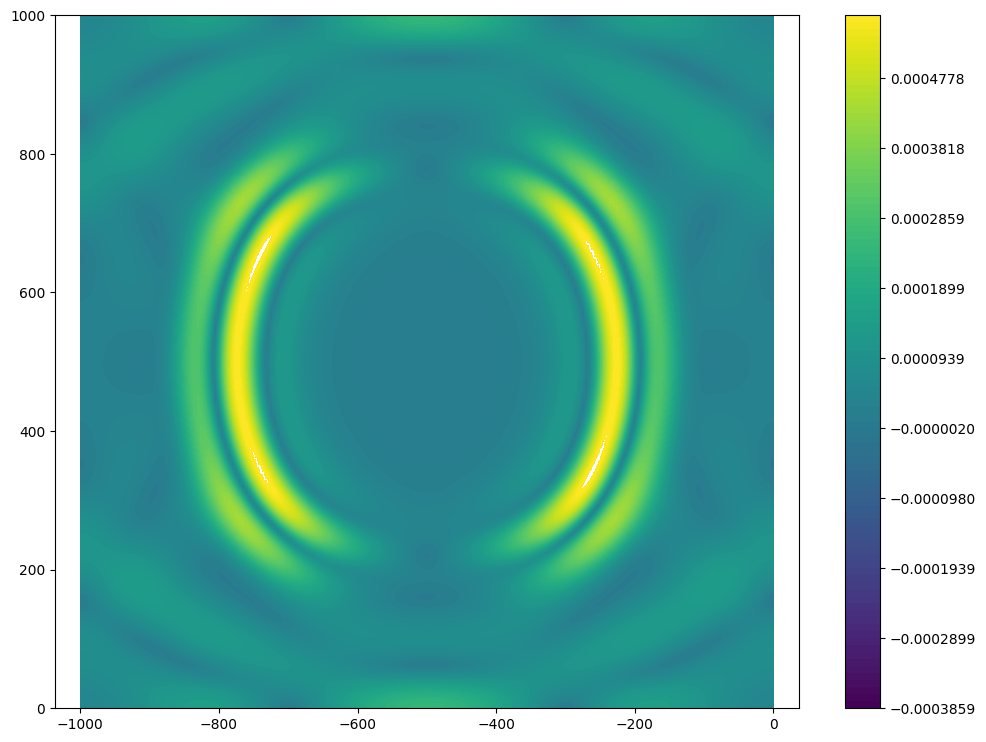

In [ ]:
vmin = np.min(anisotropic_elastic_wave.u_n.dat.data)
vmax = np.max(anisotropic_elastic_wave.u_n.dat.data)   

fig = plt.figure(figsize=(12, 9))
axes = fig.add_subplot(111)
levels = np.linspace(vmin, vmax, 100)
contours = tricontourf(
        anisotropic_elastic_wave.u_n, 
        axes=axes,
        levels=levels,
        vmin=vmin,
        vmax=vmax
    )
axes.axis('equal')
cbar = plt.colorbar(contours, ax=axes)

In the following figures, we compare the elastic isotropic and anisotropic results:

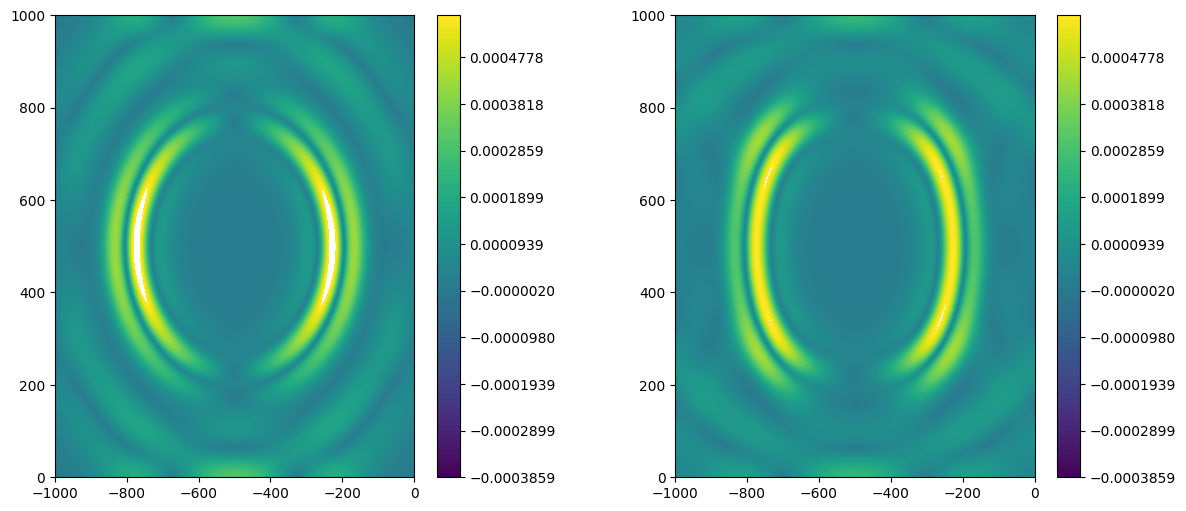

In [ ]:
fig = plt.figure(figsize=(12, 6))
subfigs = fig.subfigures(1, 2, wspace=0.07)

ax0 = subfigs[0].add_subplot(111)
contours1 = tricontourf(
    elastic_wave.u_n,
    axes=ax0,
    levels=levels,
    vmin=vmin,
    vmax=vmax
)
plt.colorbar(contours1, ax=ax0)

ax1 = subfigs[1].add_subplot(111)
contours2 = tricontourf(
    anisotropic_elastic_wave.u_n,
    axes=ax1,
    levels=levels,
    vmin=vmin,
    vmax=vmax
)
plt.colorbar(contours2, ax=ax1)

plt.show()

To simulate viscoelastic wave propagation in anisotropic media, we define the following dictionary:

In [ ]:
anisotropic_viscoelastic_dictionary = anisotropic_elastic_dictionary.copy()

The dictionary already contains the main anisotropy parameters. We can now add the attenuation parameters:

In [ ]:
anisotropic_viscoelastic_dictionary["viscoelastic"] = True
anisotropic_viscoelastic_dictionary["synthetic_data"]["Q_epsilon"] = 1/Q0
anisotropic_viscoelastic_dictionary["synthetic_data"]["Q_delta"] = 1/Q0
anisotropic_viscoelastic_dictionary["synthetic_data"]["Q_gamma"] = 1/Q0

anisotropic_viscoelastic_dictionary["viscoelasticity"] = {
    "visco_type": "maxwell_gsls_Q", 
    "branches": L,
    "omega_gsls": omega_relax,
    "y_gsls": y
}


Now we run the wave propagation:

In [ ]:
anisotropic_viscoelastic_wave = spyro.AnisotropicVTIWave(anisotropic_viscoelastic_dictionary)

anisotropic_viscoelastic_wave.set_mesh(input_mesh_parameters={"edge_length": dx_target, "periodic": True})
anisotropic_viscoelastic_wave.forward_solve()

Parallelism type: automatic
No Absorbing Boundary Conditions (ABCs) applied.
Pad length will be determined with HABC criterion
Mesh incomplete: 'firedrake_mesh' requires either 'edge_length' or 'cells_per_wavelength'.
Mesh incomplete: 'firedrake_mesh' requires either 'edge_length' or 'cells_per_wavelength'.
Skipping mesh generation, since we don't have all the parameters
Creating firedrake_mesh type mesh.


/workspaces/viscoelasticity_and_parameters/spyro/solvers/wave.py:171: UserWarning: No mesh file, Firedrake mesh will be automatically generated.
  warnings.warn(


Mesh Created with 10000 Nodes and 20000 Area Elements

Solving Forward Problem
[0.05]
Viscoelastic Maxwell GSLS
Saving Displacement in: results/forward_outputsn[0].pvd
Simulation time is:        0.0 seconds
Simulation time is:       0.05 seconds
Simulation time is:        0.1 seconds
Simulation time is:       0.15 seconds
Simulation time is:        0.2 seconds
Simulation time is:       0.25 seconds
Simulation time is:        0.3 seconds
Simulation time is:       0.35 seconds
Simulation time is:        0.4 seconds


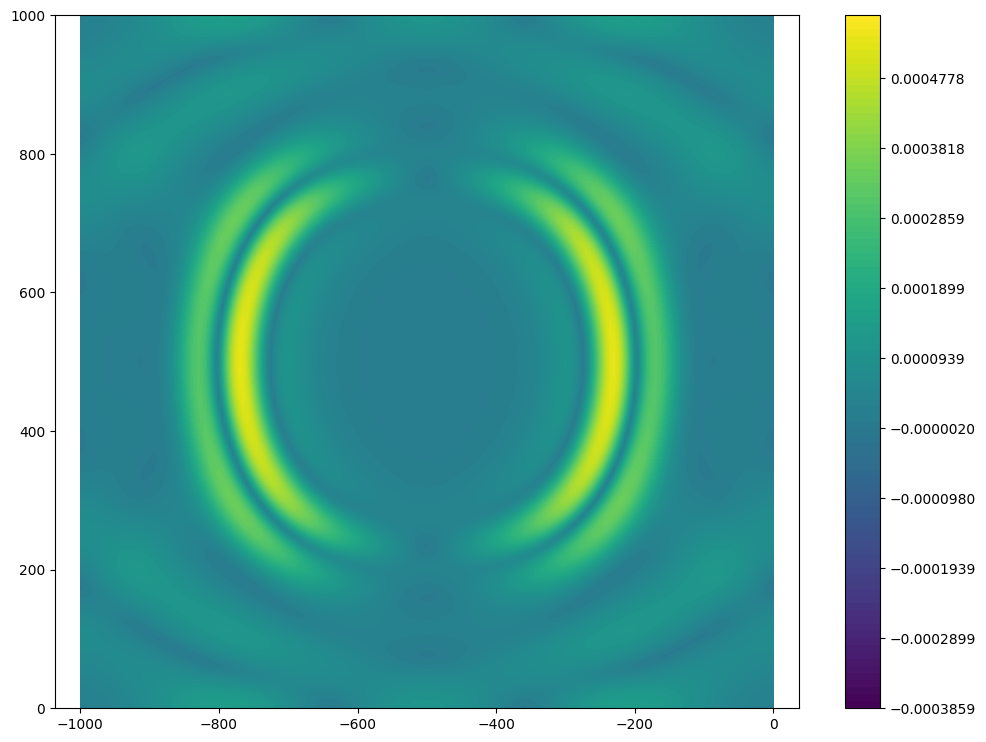

In [ ]:
fig = plt.figure(figsize=(12, 9))
axes = fig.add_subplot(111)
levels = np.linspace(vmin, vmax, 100)
contours = tricontourf(
        anisotropic_viscoelastic_wave.u_n, 
        axes=axes,
        levels=levels,
        vmin=vmin,
        vmax=vmax
    )
axes.axis('equal')
cbar = plt.colorbar(contours, ax=axes)

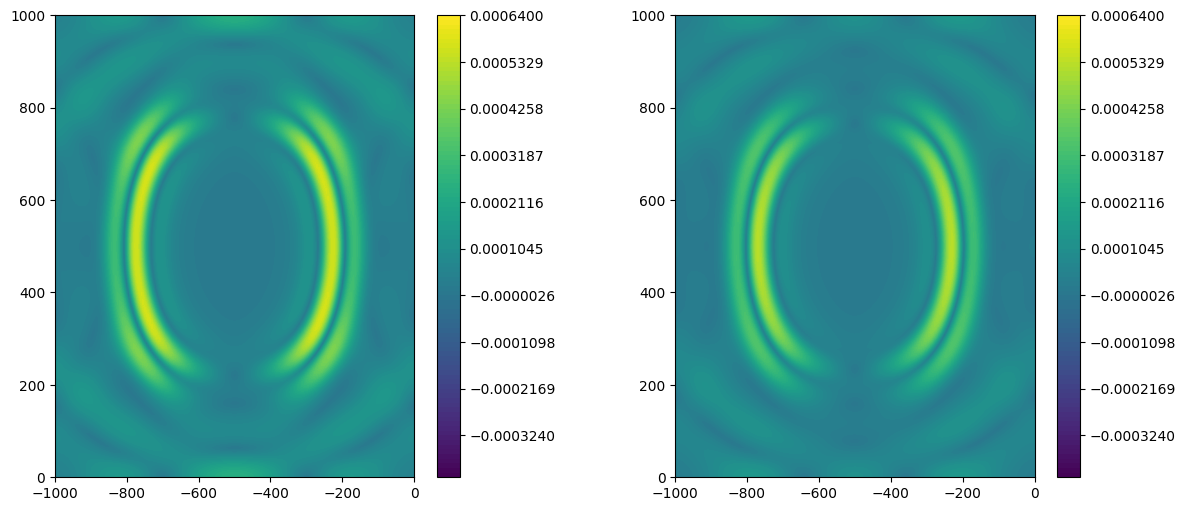

In [ ]:
vmin = np.min(elastic_wave.u_n.dat.data)
vmax = np.max(elastic_wave.u_n.dat.data)
levels = np.linspace(vmin, vmax, 100)

fig = plt.figure(figsize=(12, 6))
subfigs = fig.subfigures(1, 2, wspace=0.07)

ax0 = subfigs[0].add_subplot(111)
contours1 = tricontourf(
    anisotropic_elastic_wave.u_n,
    axes=ax0,
    levels=levels,
    vmin=vmin,
    vmax=vmax
)
plt.colorbar(contours1, ax=ax0)

ax1 = subfigs[1].add_subplot(111)
contours2 = tricontourf(
    anisotropic_viscoelastic_wave.u_n,
    axes=ax1,
    levels=levels,
    vmin=vmin,
    vmax=vmax
)
plt.colorbar(contours2, ax=ax1)

plt.show()

We can also compare the information on the central receiver:

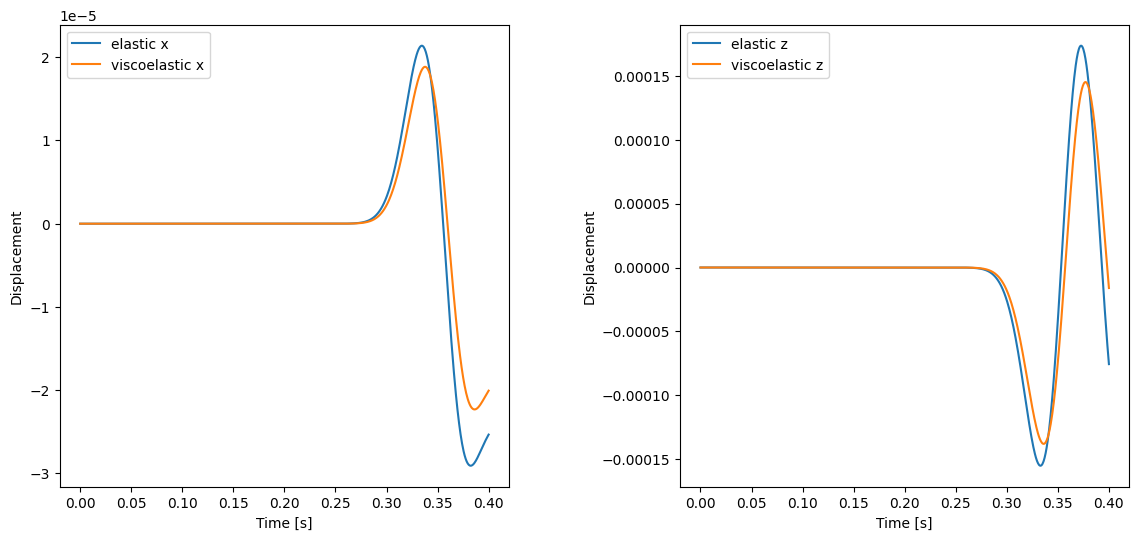

In [ ]:
time_vector = get_time_vector(anisotropic_elastic_wave)

# receiver data: shape usually (n_times, n_components)
elastic_data = anisotropic_elastic_wave.forward_solution_receivers[:, 15, :]
visco_data = anisotropic_viscoelastic_wave.forward_solution_receivers[:, 15, :]

fig = plt.figure(figsize=(12, 6))
subfigs = fig.subfigures(1, 2, wspace=0.07)

ax0 = subfigs[0].add_subplot(111)
ax1 = subfigs[1].add_subplot(111)

ax0.plot(time_vector, elastic_data[:, 0], label="elastic x")
ax0.plot(time_vector, visco_data[:, 0], label="viscoelastic x")

ax1.plot(time_vector, elastic_data[:, 1], label="elastic z")
ax1.plot(time_vector, visco_data[:, 1], label="viscoelastic z")

ax0.set_xlabel("Time [s]")
ax0.set_ylabel("Displacement")
ax0.legend()
ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Displacement")
ax1 .legend()
plt.show()

The implementation also supports weak anisotropy, in which we set `"anisotropy"` to `"weak"` instead of `"exact"`.

Finally, we can also simulate wave propagation in TTI media. We begin with the elastic case:

In [ ]:
anisotropic_elastic_TTI_dictionary = anisotropic_elastic_dictionary.copy()

For the TTI case, we change the wave type from `"anisotropic_VTI"` to `"anisotropic_TTI"` and add the parameters $\theta$ and $\phi$:

In [ ]:
anisotropic_elastic_TTI_dictionary["wave_type"] = "anisotropic_TTI"
anisotropic_elastic_TTI_dictionary["synthetic_data"]['theta'] = 30.0
anisotropic_elastic_TTI_dictionary["synthetic_data"]['phi'] = 0.0

In [ ]:
anisotropic_elastic_TTI_wave = spyro.AnisotropicTTIWave(anisotropic_elastic_TTI_dictionary)

anisotropic_elastic_TTI_wave.set_mesh(input_mesh_parameters={"edge_length": dx_target, "periodic": True})

anisotropic_elastic_TTI_wave.forward_solve()

Parallelism type: automatic
No Absorbing Boundary Conditions (ABCs) applied.
Pad length will be determined with HABC criterion
Mesh incomplete: 'firedrake_mesh' requires either 'edge_length' or 'cells_per_wavelength'.
Mesh incomplete: 'firedrake_mesh' requires either 'edge_length' or 'cells_per_wavelength'.
Skipping mesh generation, since we don't have all the parameters
Creating firedrake_mesh type mesh.


/workspaces/viscoelasticity_and_parameters/spyro/solvers/wave.py:171: UserWarning: No mesh file, Firedrake mesh will be automatically generated.
  warnings.warn(


Mesh Created with 10000 Nodes and 20000 Area Elements

Solving Forward Problem
Saving Displacement in: results/forward_outputsn[0].pvd
Simulation time is:        0.0 seconds
Simulation time is:       0.05 seconds
Simulation time is:        0.1 seconds
Simulation time is:       0.15 seconds
Simulation time is:        0.2 seconds
Simulation time is:       0.25 seconds
Simulation time is:        0.3 seconds
Simulation time is:       0.35 seconds
Simulation time is:        0.4 seconds


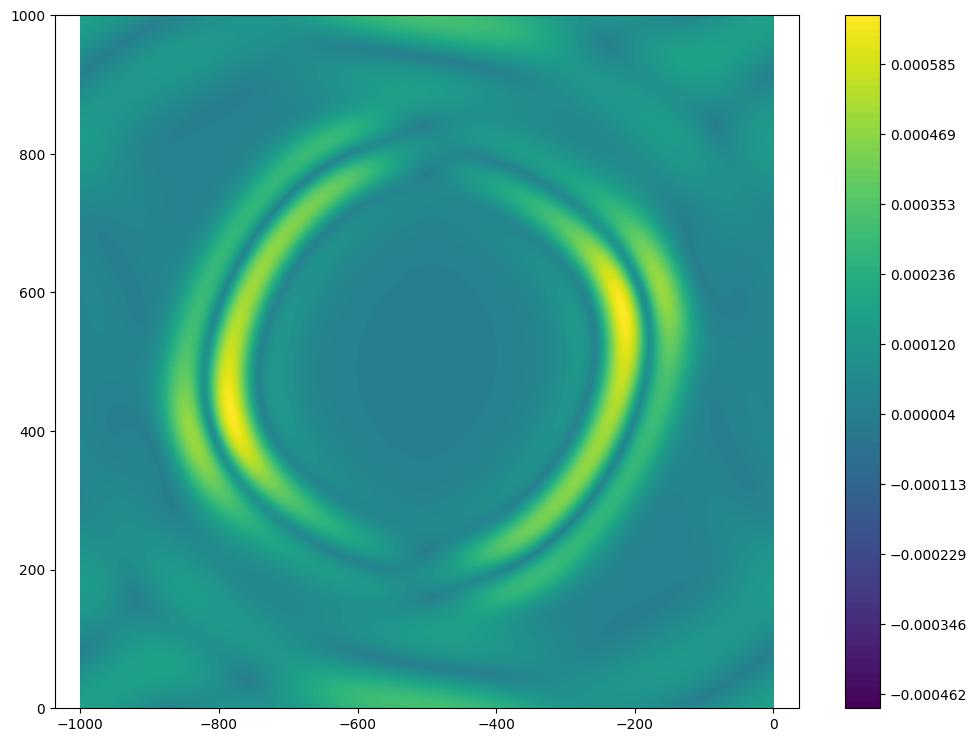

In [ ]:
vmin = np.min(anisotropic_elastic_TTI_wave.u_n.dat.data)
vmax = np.max(anisotropic_elastic_TTI_wave.u_n.dat.data)   

fig = plt.figure(figsize=(12, 9))
axes = fig.add_subplot(111)
levels = np.linspace(vmin, vmax, 100)
contours = tricontourf(
        anisotropic_elastic_TTI_wave.u_n, 
        axes=axes,
        levels=levels,
        vmin=vmin,
        vmax=vmax
    )
axes.axis('equal')
cbar = plt.colorbar(contours, ax=axes)

For the viscoelastic case, we simply copy the previously defined dictionary and add the viscoelasticity parameters:

In [ ]:
anisotropic_viscoelastic_TTI_dictionary = anisotropic_elastic_TTI_dictionary.copy()

anisotropic_viscoelastic_TTI_dictionary["viscoelastic"] = True
anisotropic_viscoelastic_TTI_dictionary["synthetic_data"]["Q_epsilon"] = 1/Q0
anisotropic_viscoelastic_TTI_dictionary["synthetic_data"]["Q_delta"] = 1/Q0
anisotropic_viscoelastic_TTI_dictionary["synthetic_data"]["Q_gamma"] = 1/Q0

anisotropic_viscoelastic_TTI_dictionary["viscoelasticity"] = {
    "visco_type": "maxwell_gsls_Q",
    "branches": L,
    "omega_gsls": omega_relax,
    "y_gsls": y
}

In [ ]:
anisotropic_viscoelastic_TTI_wave = spyro.AnisotropicTTIWave(anisotropic_viscoelastic_TTI_dictionary)

anisotropic_viscoelastic_TTI_wave.set_mesh(input_mesh_parameters={"edge_length": dx_target, "periodic": True})

anisotropic_viscoelastic_TTI_wave.forward_solve()

Parallelism type: automatic
No Absorbing Boundary Conditions (ABCs) applied.
Pad length will be determined with HABC criterion
Mesh incomplete: 'firedrake_mesh' requires either 'edge_length' or 'cells_per_wavelength'.
Mesh incomplete: 'firedrake_mesh' requires either 'edge_length' or 'cells_per_wavelength'.
Skipping mesh generation, since we don't have all the parameters
Creating firedrake_mesh type mesh.


/workspaces/viscoelasticity_and_parameters/spyro/solvers/wave.py:171: UserWarning: No mesh file, Firedrake mesh will be automatically generated.
  warnings.warn(


Mesh Created with 10000 Nodes and 20000 Area Elements

Solving Forward Problem
[0.05]
Viscoelastic Maxwell GSLS
Saving Displacement in: results/forward_outputsn[0].pvd
Simulation time is:        0.0 seconds
Simulation time is:       0.05 seconds
Simulation time is:        0.1 seconds
Simulation time is:       0.15 seconds
Simulation time is:        0.2 seconds
Simulation time is:       0.25 seconds
Simulation time is:        0.3 seconds
Simulation time is:       0.35 seconds
Simulation time is:        0.4 seconds


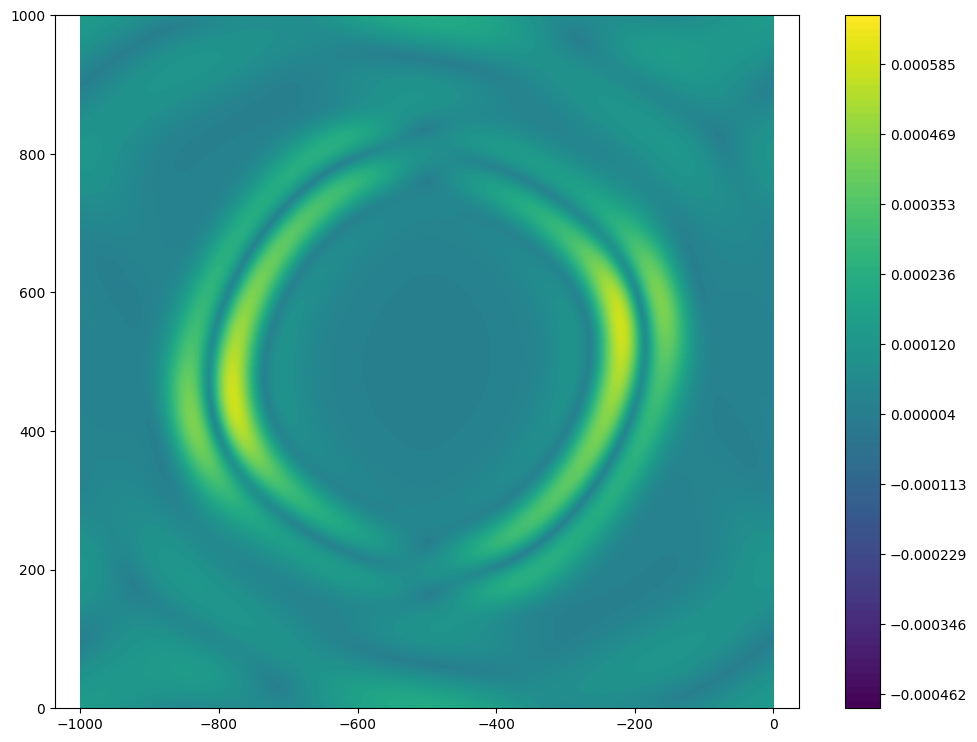

In [ ]:
fig = plt.figure(figsize=(12, 9))
axes = fig.add_subplot(111)
levels = np.linspace(vmin, vmax, 100)
contours = tricontourf(
        anisotropic_viscoelastic_TTI_wave.u_n, 
        axes=axes,
        levels=levels,
        vmin=vmin,
        vmax=vmax
    )
axes.axis('equal')
cbar = plt.colorbar(contours, ax=axes)

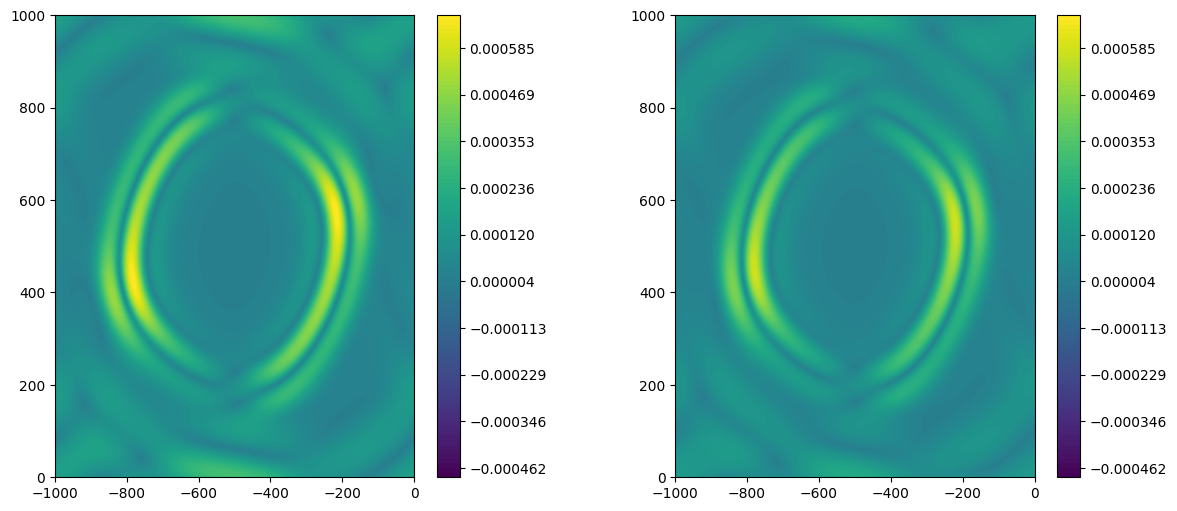

In [ ]:
vmin = np.min(anisotropic_elastic_TTI_wave.u_n.dat.data)
vmax = np.max(anisotropic_elastic_TTI_wave.u_n.dat.data)
levels = np.linspace(vmin, vmax, 100)

fig = plt.figure(figsize=(12, 6))
subfigs = fig.subfigures(1, 2, wspace=0.07)

ax0 = subfigs[0].add_subplot(111)
contours1 = tricontourf(
    anisotropic_elastic_TTI_wave.u_n,
    axes=ax0,
    levels=levels,
    vmin=vmin,
    vmax=vmax
)
plt.colorbar(contours1, ax=ax0)

ax1 = subfigs[1].add_subplot(111)
contours2 = tricontourf(
    anisotropic_viscoelastic_TTI_wave.u_n,
    axes=ax1,
    levels=levels,
    vmin=vmin,
    vmax=vmax
)
plt.colorbar(contours2, ax=ax1)

plt.show()

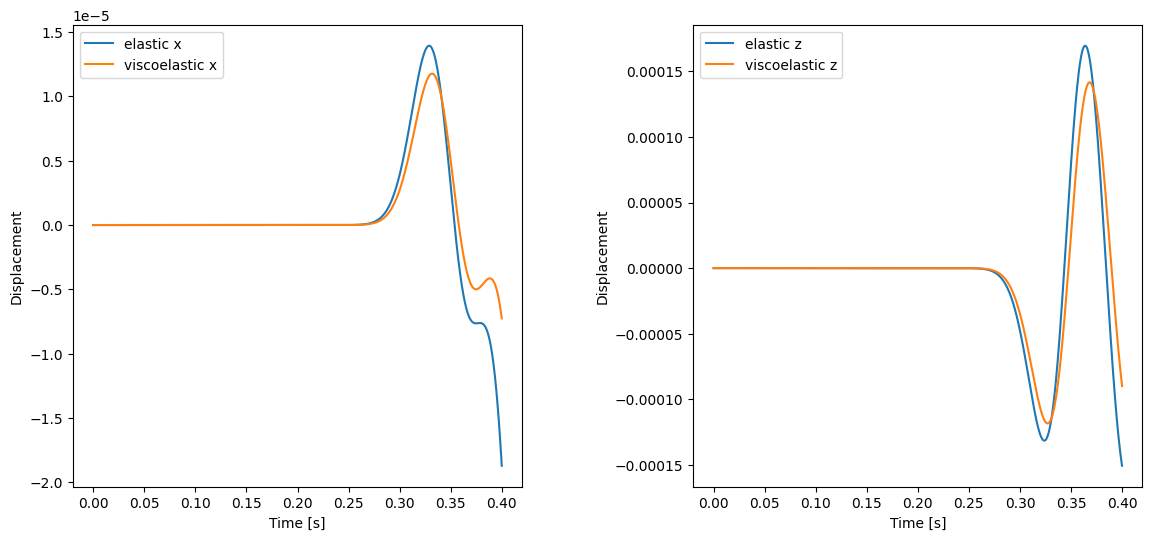

In [ ]:
time_vector = get_time_vector(anisotropic_elastic_TTI_wave)

elastic_data = anisotropic_elastic_TTI_wave.forward_solution_receivers[:, 15, :]
visco_data = anisotropic_viscoelastic_TTI_wave.forward_solution_receivers[:, 15, :]

fig = plt.figure(figsize=(12, 6))
subfigs = fig.subfigures(1, 2, wspace=0.07)

ax0 = subfigs[0].add_subplot(111)
ax1 = subfigs[1].add_subplot(111)

ax0.plot(time_vector, elastic_data[:, 0], label="elastic x")
ax0.plot(time_vector, visco_data[:, 0], label="viscoelastic x")

ax1.plot(time_vector, elastic_data[:, 1], label="elastic z")
ax1.plot(time_vector, visco_data[:, 1], label="viscoelastic z")

ax0.set_xlabel("Time [s]")
ax0.set_ylabel("Displacement")
ax0.legend()
ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Displacement")
ax1 .legend()
plt.show()